In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import seaborn as sns
from pathlib import Path
import csv

import json
from pathlib import Path

# Set matplotlib font to Avenir
import matplotlib.font_manager as fm
import matplotlib as mpl
from sklearn.metrics import r2_score


In [3]:
#### plot style
def set_plot_style():
    """Set clean plotting style similar to GPG style."""
    plt.rcParams.update({
        "figure.figsize": (3.5, 3.2),
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "axes.linewidth": 1.0,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.major.size": 4,
        "ytick.major.size": 4,
        "xtick.minor.visible": True,
        "ytick.minor.visible": False,
        "axes.grid": False,
        "legend.frameon": False,
    })



# Overall review

In [17]:
# Get all run directories
optimization_runs_dir = Path('./build_gnn_model/optimization_runs/')
run_dirs = [d for d in optimization_runs_dir.iterdir() if d.is_dir() and d.name.startswith('run_')]
print(run_dirs)

# Collect results from all runs
results_data = []

for run_dir in sorted(run_dirs):
    metrics_file = run_dir / 'final_metrics.json'
    predictions_file = run_dir / 'predictions' / 'all_predictions.csv'
    
    if metrics_file.exists():
        try:
            with open(metrics_file, 'r') as f:
                metrics = json.load(f)
            
            # Get split counts from predictions file if it exists
            train_count = val_count = test_count = None
            if predictions_file.exists():
                try:
                    pred_df = pd.read_csv(predictions_file)
                    split_counts = pred_df['split'].value_counts()
                    train_count = split_counts.get('train', 0).astype(int)
                    val_count = split_counts.get('val', 0).astype(int)
                    test_count = split_counts.get('test', 0).astype(int)
                except Exception as e:
                    print(f"Error reading predictions file {predictions_file}: {e}")
            
            # Extract metrics for each split
            result_row = {
                'run_name': "_".join(run_dir.name.split('_')[3:]),
                'train_count': train_count,
                'val_count': val_count,
                'test_count': test_count,
                'train_r2': metrics.get('train', {}).get('r2', None),
                'train_mae': metrics.get('train', {}).get('mae', None),
                'val_r2': metrics.get('val', {}).get('r2', None),
                'val_mae': metrics.get('val', {}).get('mae', None),
                'test_r2': metrics.get('test', {}).get('r2', None),
                'test_mae': metrics.get('test', {}).get('mae', None)
            }
            results_data.append(result_row)
        except (json.JSONDecodeError, KeyError) as e:
            print(f"Error reading {metrics_file}: {e}")

# Create DataFrame and display
results_summary_df = pd.DataFrame(results_data)

# Sort by test R2 (descending) for better visualization
results_summary_df = results_summary_df.sort_values(['test_r2','test_mae'], ascending=[False,True])

print(f"Found {len(results_summary_df)} optimization runs with results:")
print("\nOptimization Run Results Summary:")
print("=" * 120)

# Display with better formatting
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.4f}'.format)

results_summary_df

[PosixPath('build_gnn_model/optimization_runs/run_20250905_185713')]
Found 1 optimization runs with results:

Optimization Run Results Summary:


,run_name,train_count,val_count,test_count,train_r2,train_mae,val_r2,val_mae,test_r2,test_mae
0,,832,93,106,0.9867,0.0824,0.8397,0.2388,0.5170,0.5231


In [ ]:
# results_summary_df.to_csv('results_summary_df.csv', index=False)

# Plot results

In [23]:
#### import visualization.py
import sys
import os
sys.path.append(os.path.dirname(os.path.abspath('')))
from build_gnn_model.visualization import plot_parity_mae, calculate_metrics, set_plot_style, plot_parity

In [24]:
results_df = pd.read_csv(f'{run_dirs[0]}/predictions/all_predictions.csv')
results_df.head()

,sample_name,true_hte_lnk,predicted_hte_lnk,split
0,rxn_10_10,2.0769,2.0077,train
1,rxn_10_11,0.5458,0.5727,train
2,rxn_10_12,1.0635,0.9971,train
3,rxn_10_13,1.8559,1.7022,train
4,rxn_10_14,0.8681,0.7781,train


In [32]:
# Extract data for each split
train_data = results_df[results_df['split'] == 'train']
val_data = results_df[results_df['split'] == 'val']
test_data = results_df[results_df['split'] == 'test']

# Extract true and predicted values for each split
y_true_train = train_data['true_hte_lnk'].values
y_pred_train = train_data['predicted_hte_lnk'].values

y_true_val = val_data['true_hte_lnk'].values
y_pred_val = val_data['predicted_hte_lnk'].values

y_true_test = test_data['true_hte_lnk'].values
y_pred_test = test_data['predicted_hte_lnk'].values

# Create parity plot
plot_parity(y_true_train, y_pred_train, 
                y_true_val, y_pred_val,
                y_true_test, y_pred_test,
                output_path="build_gnn_model/plots/parity_plot.png", 
                title="GNN Reaction Rate Predictions")


R²: 0.987, MAE: 0.082, RMSE: 0.107
R²: 0.840, MAE: 0.239, RMSE: 0.326
R²: 0.517, MAE: 0.523, RMSE: 0.657

o Saved parity plot: build_gnn_model/plots/parity_plot.png


(np.float64(0.9867071982650364),
 np.float64(0.08236967465456731),
 np.float64(0.8396614341142308),
 np.float64(0.23883310407526875),
 np.float64(0.5170214539607583),
 np.float64(0.5230664994056604))

# Find Drug Scope predictions
From the measurable PRISM coupling rate predictions, compare the true to the predicted PRISM rates.

In [27]:
sample_names = ['rxn_14_56',
                'rxn_22_56',
                'rxn_7_56']

drug_scope_preds = results_df[results_df['sample_name'].isin(sample_names)]

# Calculate metrics for drug scope predictions
drug_scope_preds['true_HTE_rate'] = 10**drug_scope_preds['true_hte_lnk']
drug_scope_preds['pred_HTE_rate'] = 10**drug_scope_preds['predicted_hte_lnk']
drug_scope_preds.head()

/var/folders/td/4_0_xh_n517__4kkqln79qs80000gn/T/ipykernel_79860/2667291485.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drug_scope_preds['true_HTE_rate'] = 10**drug_scope_preds['true_hte_lnk']
/var/folders/td/4_0_xh_n517__4kkqln79qs80000gn/T/ipykernel_79860/2667291485.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drug_scope_preds['pred_HTE_rate'] = 10**drug_scope_preds['predicted_hte_lnk']


,sample_name,true_hte_lnk,predicted_hte_lnk,split,true_HTE_rate,pred_HTE_rate
930,rxn_14_56,1.7195,2.6040,test,52.4256,401.8225
950,rxn_22_56,0.5464,0.3541,test,3.5185,2.2601
1028,rxn_7_56,2.1596,0.5541,test,144.4191,3.5815


# Individual Review

In [28]:
# Find outliers in the test set 1 (greater than 2 standard deviations)
actual = results_df['true_hte_lnk']
predicted = results_df['predicted_hte_lnk']
errors = actual - predicted
mean_error = np.mean(errors)
std_error = np.std(errors)


out_threshold = 2.0
# Identify outliers (errors greater than 2 standard deviations)
outlier_threshold = out_threshold * std_error
outliers = results_df[np.abs(errors - mean_error) > outlier_threshold].copy()
print(f"Number of outliers: {len(outliers)}")

# Sort by absolute error to see the worst predictions
outliers['error'] = outliers['true_hte_lnk'] - outliers['predicted_hte_lnk']
outliers = outliers.sort_values('error', ascending=False)

# Display the outliers with relevant columns
display_cols = ['sample_name', 'true_hte_lnk', 'predicted_hte_lnk', 'error']
outliers[display_cols].head()

Number of outliers: 62


,sample_name,true_hte_lnk,predicted_hte_lnk,error
1028,rxn_7_56,2.1596,0.5541,1.6056
1008,rxn_42_44,3.3066,1.8595,1.4471
971,rxn_34_38,3.5843,2.2659,1.3184
1009,rxn_42_45,2.3652,1.0505,1.3147
1007,rxn_42_43,3.5843,2.3491,1.2352


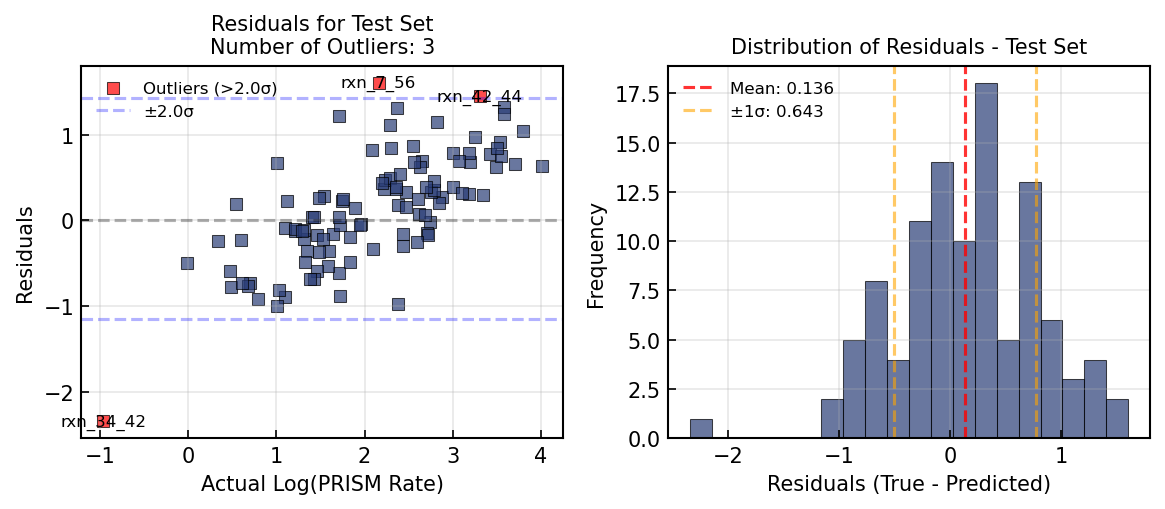

Residuals Statistics:
Mean: 0.1359
Standard Deviation: 0.6428
Min: -2.3410
Max: 1.6056
Number of samples: 106


In [34]:
# Extract actual and predicted values from test set
test_data = results_df[results_df['split'] == 'test']
actual_values_tt = test_data['true_hte_lnk']
predicted_values_tt = test_data['predicted_hte_lnk']
errors_tt = actual_values_tt - predicted_values_tt
mean_error_tt = np.mean(errors_tt)
std_error_tt = np.std(errors_tt)
outlier_threshold_tt = out_threshold * std_error_tt
crest_colors = ['#9ECA91', '#2A3D77',  '#48988F', '#AA183B']  

# Create a mask for outliers (errors greater than 2 standard deviations)
outlier_mask_tt = np.abs(errors_tt - mean_error_tt) > outlier_threshold_tt
outliers_tt = test_data[outlier_mask_tt].copy()
outliers_tt['error'] = outliers_tt['true_hte_lnk'] - outliers_tt['predicted_hte_lnk']

#### Create figure with two subplots
set_plot_style()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))

#### Left subplot: Residuals plot for Test Set
ax1.scatter(actual_values_tt[~outlier_mask_tt], errors_tt[~outlier_mask_tt], marker='s',
            color=crest_colors[1], alpha=0.7, edgecolor='k', linewidth=0.5)

# Plot outliers in red
ax1.scatter(actual_values_tt[outlier_mask_tt], errors_tt[outlier_mask_tt], marker='s',
            color='red', alpha=0.7, edgecolor='k', linewidth=0.5, label=f'Outliers (>{out_threshold}σ)')

# Add horizontal lines for the threshold boundaries
ax1.axhline(y=mean_error_tt + outlier_threshold_tt, color='b', linestyle='--', alpha=0.3)
ax1.axhline(y=mean_error_tt - outlier_threshold_tt, color='b', linestyle='--', alpha=0.3, label=f'±{out_threshold}σ')

# Add the label of the outliers
for i, row in outliers_tt.iterrows():
    ax1.text(row['true_hte_lnk'], row['error'] - 0.1, row['sample_name'], fontsize=8, ha='center', va='bottom')

# Number of outliers
n_outliers_tt = len(outliers_tt)

ax1.set_xlabel('Actual Log(PRISM Rate)', fontsize=10)
ax1.set_ylabel('Residuals', fontsize=10)
ax1.set_title(f'Residuals for Test Set\nNumber of Outliers: {n_outliers_tt}', fontsize=10)
ax1.axhline(y=0, color='k', linestyle='--', alpha=0.3)  # Add a horizontal line at y=0
ax1.legend(fontsize=8, loc='upper left')
ax1.grid(True, alpha=0.3)

#### Right subplot: Distribution of residuals for test set
residuals_test = test_data['true_hte_lnk'] - test_data['predicted_hte_lnk']

# Create histogram
ax2.hist(residuals_test, bins=20, color=crest_colors[1], alpha=0.7, edgecolor='k', linewidth=0.5)

# Add vertical lines for mean and standard deviation
mean_residual = np.mean(residuals_test)
std_residual = np.std(residuals_test)

ax2.axvline(x=mean_residual, color='red', linestyle='--', alpha=0.8, label=f'Mean: {mean_residual:.3f}')
ax2.axvline(x=mean_residual + std_residual, color='orange', linestyle='--', alpha=0.6, label=f'±1σ: {std_residual:.3f}')
ax2.axvline(x=mean_residual - std_residual, color='orange', linestyle='--', alpha=0.6)

ax2.set_xlabel('Residuals (True - Predicted)', fontsize=10)
ax2.set_ylabel('Frequency', fontsize=10)
ax2.set_title('Distribution of Residuals - Test Set', fontsize=10)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('build_gnn_model/plots/Fig_SX_residuals_test_set_combined.png', dpi=300, bbox_inches='tight')
plt.show()

# Print some statistics
print(f"Residuals Statistics:")
print(f"Mean: {mean_residual:.4f}")
print(f"Standard Deviation: {std_residual:.4f}")
print(f"Min: {np.min(residuals_test):.4f}")
print(f"Max: {np.max(residuals_test):.4f}")
print(f"Number of samples: {len(residuals_test)}")

In [33]:
# Extract data for each split
train_data = results_df[results_df['split'] == 'train']
val_data = results_df[results_df['split'] == 'val']
test_data = results_df[results_df['split'] == 'test']

# Remove outliers from test data (using the outlier_mask_tt from previous cell)
test_data_clean = test_data[~outlier_mask_tt]

# Extract true and predicted values for each split
y_true_train = train_data['true_hte_lnk'].values
y_pred_train = train_data['predicted_hte_lnk'].values

y_true_val = val_data['true_hte_lnk'].values
y_pred_val = val_data['predicted_hte_lnk'].values

y_true_test = test_data_clean['true_hte_lnk'].values
y_pred_test = test_data_clean['predicted_hte_lnk'].values

# Create parity plot
plot_parity(y_true_train, y_pred_train, 
                y_true_val, y_pred_val,
                y_true_test, y_pred_test,
                output_path="build_gnn_model/plots/parity_plot_after-outliers-removed.png", 
                title="GNN Reaction Rate Predictions")


R²: 0.987, MAE: 0.082, RMSE: 0.107
R²: 0.840, MAE: 0.239, RMSE: 0.326
R²: 0.576, MAE: 0.486, RMSE: 0.588

o Saved parity plot: build_gnn_model/plots/parity_plot_after-outliers-removed.png


(np.float64(0.9867071982650364),
 np.float64(0.08236967465456731),
 np.float64(0.8396614341142308),
 np.float64(0.23883310407526875),
 np.float64(0.5756351093133956),
 np.float64(0.48593547288349526))

In [31]:
test_data[outlier_mask_tt].head()

,sample_name,true_hte_lnk,predicted_hte_lnk,split
974,rxn_34_42,-0.9661,1.3749,test
1008,rxn_42_44,3.3066,1.8595,test
1028,rxn_7_56,2.1596,0.5541,test
